# Trajectory Analysis for Incremental Training

In [1]:
0

0

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import sys
import logging
import subprocess
import gc
import os
import time
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
import pickle
import itertools
import torch
import tqdm
import scvi
import h5py
from scipy import stats

sc.settings.verbose = 3

In [4]:
working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)
sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

from helper.constants import metrics_scib, metric_direction_dict
from helper.plot_metrics_gridspec import plot_metrics_gridspec

from tardis_weight_scan.helper.plotting import plot_summary_ci, plot_umap_grid, normalize_and_align

2025-05-12 13:25:52.971 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-05-12 13:25:52.972 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [5]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [6]:
print(f"CUDA used: {torch.cuda.is_available()}")

dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

CUDA used: True


In [7]:
definitions_path = os.path.join(dataset_dir, f"incremental_analysis_definitions_dict.pkl")
with open(definitions_path, "rb") as _file_definitions:
    definitions = pickle.load(_file_definitions)    

In [8]:
definitions

{'tardis_sciplex': {'training_anndata_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental_training_anndata.h5ad',
  'vae_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental',
  'pickle_paths_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental_paths.pkl',
  'trajectory_object_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/tardis_cpa_sciplex_v2_encode_incremental_trajectory_object.pkl',
  'label_obs_column': 'drug_dose_name',
  'batch_obs_column': 'sample'},
 'scvi_garcia': {'training_anndata_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/scvi_garcia_incremental_with_callback_training_anndata.h5ad',
  'vae_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/scvi_garcia_incremental_with_callback',
  'pickle_paths_path': '/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data/scvi

# Loading the benchmarking

In [9]:
sort_columns_by = ["run_id", "trajectory", "training_step", "path", "metric", "score"]

In [10]:
df_sctram = pd.DataFrame()
count = 0

for run_id in definitions.keys():

    pickle_paths_path = definitions[run_id]["pickle_paths_path"]
    with open(pickle_paths_path, "rb") as _file_pickle_paths:
        steps_paths_dict = pickle.load(_file_pickle_paths)    
    trajectory_path = definitions[run_id]["trajectory_object_path"]
    
    for latent_step, latent_object_path in steps_paths_dict.items():
        
        with open(trajectory_path, "rb") as _file_trajectory_path:
            trajectories_object = pickle.load(_file_trajectory_path)
        
        for trajectory in sorted(trajectories_object.graph["trajectories"]):
            
            output_file_path = os.path.join(dataset_dir, f"metric_sctram_{run_id}_step_{latent_step}_trajectory_{trajectory}.pkl")
            df_trajectory_obsm = pd.read_pickle(output_file_path)
            df_trajectory_obsm["run_id"] = run_id
            df_trajectory_obsm["training_step"] = latent_step
            df_trajectory_obsm["trajectory"] = trajectory
            df_sctram = pd.concat([df_sctram, df_trajectory_obsm])
            count += 1

print(f" - Number of jobs obtained: {count}")

df_sctram.reset_index(drop=True, inplace=True)
df_sctram['score'] = pd.to_numeric(df_sctram['score'], errors='raise')
assert set(df_sctram["metric"].unique()) == set(metric_direction_dict.keys())

df_sctram = df_sctram[sort_columns_by]
df_sctram.sort_values(by=sort_columns_by, inplace=True, ignore_index=True)
df_sctram.reset_index(drop=True, inplace=True)

df_sctram

 - Number of jobs obtained: 1394


,run_id,trajectory,training_step,path,metric,score
0,scvi_dentategyrus,complex,3,adjacency,accuracy,0.806122
1,scvi_dentategyrus,complex,3,adjacency,average_shortest_path_difference,3.491704
2,scvi_dentategyrus,complex,3,adjacency,clustering_coeff_diff,0.156686
3,scvi_dentategyrus,complex,3,adjacency,f1_score,0.577778
4,scvi_dentategyrus,complex,3,adjacency,frobenius,5.357244
...,...,...,...,...,...,...
66907,tardis_sciplex,linear,106020,pseudotime,pearson_correlation,0.894229
66908,tardis_sciplex,linear,106020,pseudotime,r_squared,0.709287
66909,tardis_sciplex,linear,106020,pseudotime,r_squared_with_spline,0.849877
66910,tardis_sciplex,linear,106020,pseudotime,spearman_correlation,0.914785


In [11]:
df_scib = pd.DataFrame()
count = 0

for run_id in definitions.keys():

    pickle_paths_path = definitions[run_id]["pickle_paths_path"]
    with open(pickle_paths_path, "rb") as _file_pickle_paths:
        steps_paths_dict = pickle.load(_file_pickle_paths)    
    trajectory_path = definitions[run_id]["trajectory_object_path"]
    
    for latent_step, latent_object_path in steps_paths_dict.items():
        
        with open(trajectory_path, "rb") as _file_trajectory_path:
            trajectories_object = pickle.load(_file_trajectory_path)
        
        trajectories = sorted(trajectories_object.graph["trajectories"])
        trajectories += ["all_data_included"]
        
        for trajectory in trajectories:
            
            output_file_path = os.path.join(dataset_dir, f"metric_scib_{run_id}_step_{latent_step}_trajectory_{trajectory}.pkl")
            
            scib_experiment_name = f"{trajectory}_{latent_step}"
            df_scib_experiment = pd.read_pickle(output_file_path)
            df_scib_experiment = pd.DataFrame(df_scib_experiment.loc[scib_experiment_name])
            try:
                total_scib = df_scib_experiment.loc["Batch correction"][scib_experiment_name] * 0.4 + df_scib_experiment.loc["Bio conservation"][scib_experiment_name] * 0.6
            except KeyError:
                total_scib = 0.0
            df_scib_experiment['metric'] = df_scib_experiment.index
            
            df_scib_experiment.rename(columns={scib_experiment_name: "score"}, inplace=True)
            df_scib_experiment["path"] = [metrics_scib[i] for i in df_scib_experiment["metric"]]
            scib_total_dict = {"score": total_scib, "metric": "Total scIB", "path": metrics_scib["Total scIB"]}
            df_scib_experiment = pd.concat([df_scib_experiment, pd.DataFrame(pd.Series(scib_total_dict)).T], axis=0)
            df_scib_experiment.reset_index(drop=True, inplace=True)
            
            df_scib_experiment["run_id"] = run_id
            df_scib_experiment["training_step"] = latent_step
            df_scib_experiment["trajectory"] = trajectory
            df_scib = pd.concat([df_scib, df_scib_experiment])
            count += 1

print(f" - Number of jobs obtained: {count}")
df_scib.reset_index(drop=True, inplace=True)
df_scib['score'] = pd.to_numeric(df_scib['score'], errors='raise')

df_scib = df_scib[sort_columns_by]
df_scib.sort_values(by=sort_columns_by, inplace=True, ignore_index=True)
df_scib.reset_index(drop=True, inplace=True)

df_scib

 - Number of jobs obtained: 2023


,run_id,trajectory,training_step,path,metric,score
0,scvi_dentategyrus,all_data_included,3,Aggregate score,Batch correction,0.681724
1,scvi_dentategyrus,all_data_included,3,Aggregate score,Bio conservation,0.579870
2,scvi_dentategyrus,all_data_included,3,Aggregate score,Total scIB,0.620612
3,scvi_dentategyrus,all_data_included,3,Batch correction,graph_connectivity,0.816732
4,scvi_dentategyrus,all_data_included,3,Batch correction,ilisi_knn,0.593489
...,...,...,...,...,...,...
19922,tardis_sciplex,linear,106020,Bio conservation,clisi_knn,0.995874
19923,tardis_sciplex,linear,106020,Bio conservation,isolated_labels,0.597291
19924,tardis_sciplex,linear,106020,Bio conservation,nmi_ari_cluster_labels_kmeans_ari,0.537799
19925,tardis_sciplex,linear,106020,Bio conservation,nmi_ari_cluster_labels_kmeans_nmi,0.676415


# Analysis

In [9]:
scib_results_path = os.path.join(dataset_dir, f"incremental_figure_plotting_easy_access_scib.pkl")
# print(scib_results_path)
# df_scib.to_pickle(scib_results_path)

sctram_results_path = os.path.join(dataset_dir, f"incremental_figure_plotting_easy_access_sctram.pkl")
# print(sctram_results_path)
# df_sctram.to_pickle(sctram_results_path)

df_scib = pd.read_pickle(scib_results_path)
df_sctram = pd.read_pickle(sctram_results_path)

### Plots

In [115]:
df_scib_na = (
    df_scib.groupby("trajectory", group_keys=False)
      .apply(
          lambda g: normalize_and_align(g, "None"),
          include_groups=True
      )
      .reset_index(drop=True)
)

df_sctram_na = (
    df_sctram.groupby("trajectory", group_keys=False)
      .apply(
          lambda g: normalize_and_align(g, metric_direction_dict),
          include_groups=True
      )
      .reset_index(drop=True)
)

/tmp/ipykernel_3268504/1117434335.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(
/tmp/ipykernel_3268504/1117434335.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


In [116]:
df_scib_na

,run_id,trajectory,training_step,path,metric,score,z_score,aligned_score
0,scvi_dentategyrus,all_data_included,3,Aggregate score,Batch correction,0.681724,0.884027,0.884027
1,scvi_dentategyrus,all_data_included,3,Aggregate score,Bio conservation,0.579870,0.075319,0.075319
2,scvi_dentategyrus,all_data_included,3,Aggregate score,Total scIB,0.620612,1.204337,1.204337
3,scvi_dentategyrus,all_data_included,3,Batch correction,graph_connectivity,0.816732,-0.176145,-0.176145
4,scvi_dentategyrus,all_data_included,3,Batch correction,ilisi_knn,0.593489,1.612790,1.612790
...,...,...,...,...,...,...,...,...
19922,tardis_sciplex,linear,106020,Bio conservation,clisi_knn,0.995874,1.391139,1.391139
19923,tardis_sciplex,linear,106020,Bio conservation,isolated_labels,0.597291,2.547659,2.547659
19924,tardis_sciplex,linear,106020,Bio conservation,nmi_ari_cluster_labels_kmeans_ari,0.537799,1.415086,1.415086
19925,tardis_sciplex,linear,106020,Bio conservation,nmi_ari_cluster_labels_kmeans_nmi,0.676415,1.726785,1.726785


In [117]:
df_sctram_na

,run_id,trajectory,training_step,path,metric,score,z_score,aligned_score
0,scvi_dentategyrus,complex,3,adjacency,accuracy,0.806122,-3.353627,-3.353627
1,scvi_dentategyrus,complex,3,adjacency,average_shortest_path_difference,3.491704,0.341620,-0.341620
2,scvi_dentategyrus,complex,3,adjacency,clustering_coeff_diff,0.156686,3.715829,-3.715829
3,scvi_dentategyrus,complex,3,adjacency,f1_score,0.577778,-2.603154,-2.603154
4,scvi_dentategyrus,complex,3,adjacency,frobenius,5.357244,3.383335,-3.383335
...,...,...,...,...,...,...,...,...
66907,tardis_sciplex,linear,106020,pseudotime,pearson_correlation,0.894229,0.906345,0.906345
66908,tardis_sciplex,linear,106020,pseudotime,r_squared,0.709287,0.877020,0.877020
66909,tardis_sciplex,linear,106020,pseudotime,r_squared_with_spline,0.849877,1.237306,1.237306
66910,tardis_sciplex,linear,106020,pseudotime,spearman_correlation,0.914785,0.821858,0.821858


scvi_dentategyrus


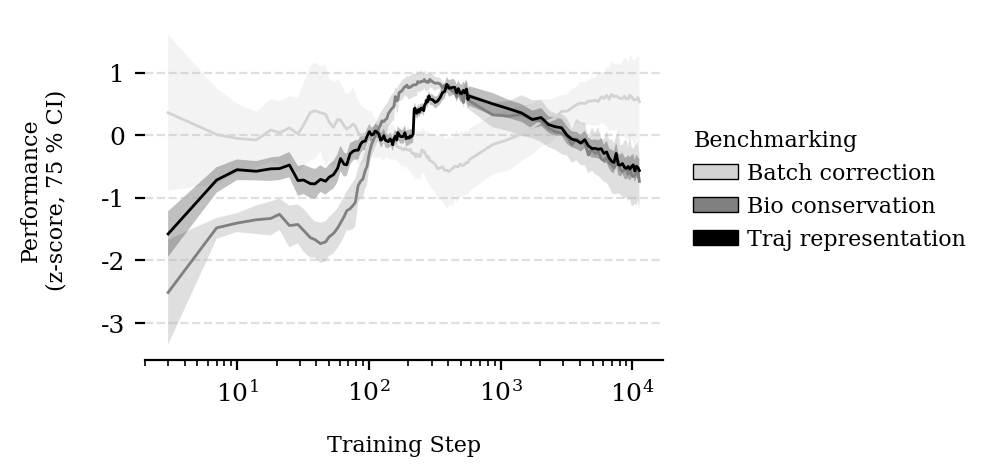

scvi_garcia


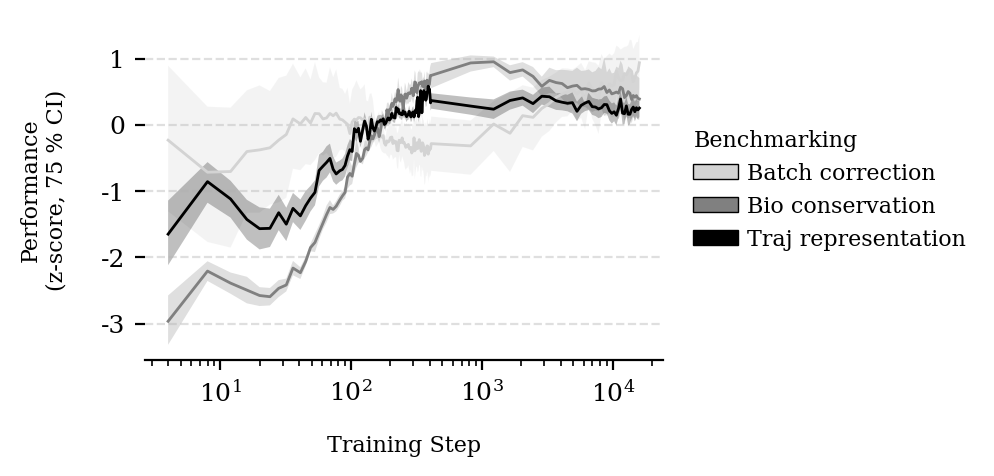

tardis_sciplex


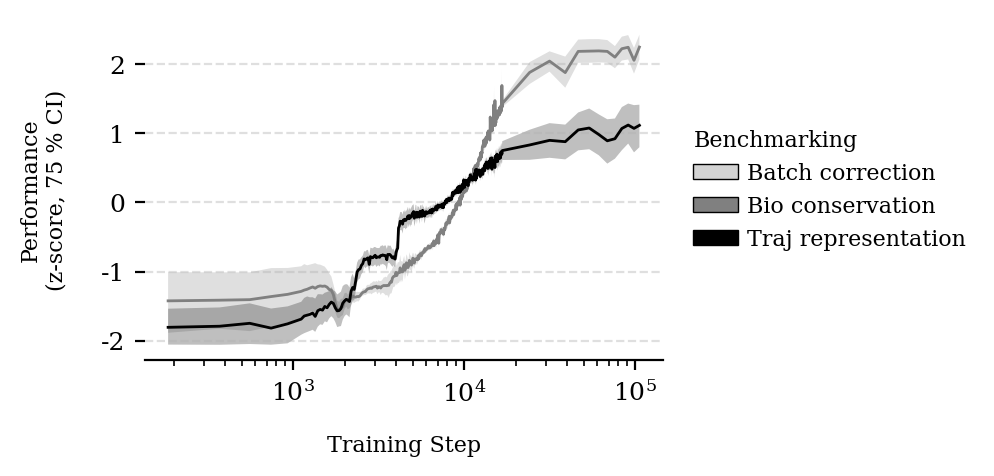

In [112]:
for df_scib_na_key in df_scib_na["run_id"].unique():
    print(df_scib_na_key)
    
    df_plot = df_scib_na[df_scib_na["run_id"]==df_scib_na_key].copy()
    df_plot = df_plot[df_plot["path"] != "Aggregate score"]
    
    df_plot2 = df_sctram_na[df_sctram_na["run_id"]==df_scib_na_key].copy()
    df_plot2["path"] = "Traj representation"
    
    df_plot = pd.concat([df_plot, df_plot2])
    # one from each, most challenging one if possible.
    df_plot = df_plot[df_plot["trajectory"].isin({"fork", "germline", "complex"})]
    
    plot_summary_ci(
        df_plot,
        figsize=(6, 2.5),
        x="training_step",
        x_label="Training Step",
        legend_title="Benchmarking",
        hue="path", 
        ci=0.75,
        line_width=1.01,
        hue_order=["Batch correction", "Bio conservation", "Traj representation"],
        color = ["lightgray", "gray", "black"]
    )
    plt.show()

### Progress Line Plots

In [113]:
# df_scib_by_dataset = {run_id: group.copy() for run_id, group in df_scib.groupby('run_id')}
# df_sctram_by_dataset = {run_id: group.copy() for run_id, group in df_sctram.groupby('run_id')}
# df_sctram_by_dataset.keys()

In [114]:
# for look_for_dataset in df_sctram_by_dataset.keys():
    
#     print("\n\n\n\n")
#     print("##################\n", look_for_dataset, "\n##################")
#     print("\n\n\n\n")
    
#     df_sctram_pivot = df_sctram_by_dataset[look_for_dataset].pivot(index=["trajectory", "path", "metric"], columns='training_step', values='score')
#     df_scib_pivot = df_scib_by_dataset[look_for_dataset].pivot(index=["trajectory", "path", "metric"], columns='training_step', values='score')
    
#     trajectories_sctram = list(df_sctram_by_dataset[look_for_dataset]["trajectory"].unique())
#     trajectories_scib = list(df_scib_by_dataset[look_for_dataset]["trajectory"].unique())
    
#     plot_metrics_gridspec(
#         df_scib_pivot, 
#         fig_height_per_metric=5,
#         n_col=4, 
#         x_axis_log_scale=True, 
#         drop_zero=True, 
#         trajectory=trajectories_scib,
#         x_range = None,
#         second_line_label_suffix="group"
#     )
    
#     plot_metrics_gridspec(
#         df_sctram_pivot, 
#         fig_height_per_metric=5,
#         n_col=4, 
#         x_axis_log_scale=True, 
#         drop_zero=True, 
#         trajectory=trajectories_sctram,
#         x_range = None,
#         second_line_label_suffix="group"
#     )